# Analyses of extremes

In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import sys
import os
import seaborn as sns
from scipy.stats import linregress
from scipy import stats
from dask import delayed
from IPython.display import display, HTML
import imageio
#from joblib import Parallel, delayed
import matplotlib.dates as mdates
import intake
from DV8_extremes import *
#DV8_functions(1) packages
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.animation import FFMpegWriter
from matplotlib import animation, rc
from IPython.display import HTML
#my functions:



import matplotlib.colors as mcolors

from tempfile import TemporaryDirectory
from getpass import getuser
from pathlib import Path
import dask
from dask.distributed import Client, LocalCluster
import bokeh
import subprocess
import re

import warnings
#warnings.filterwarnings('ignore')
scratch_dir = Path('/scratch') / getuser()[0] / getuser()

In [2]:


dask.config.config.get('distributed').get('dashboard').update({'link':'{JUPYTERHUB_SERVICE_PREFIX}/proxy/{port}/status'})
cluster = LocalCluster(n_workers=32,threads_per_worker=1)
client = Client(cluster)
client

/home/b/b382616/.local/lib/python3.10/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 36167 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /user/b382616/levante-spawner-advanced//proxy/36167/status,
Dashboard: /user/b382616/levante-spawner-advanced//proxy/36167/status,Workers: 32
Total threads: 32,Total memory: 250.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:39815,Workers: 32
Dashboard: /user/b382616/levante-spawner-advanced//proxy/36167/status,Total threads: 32
Started: Just now,Total memory: 250.00 GiB
Comm: tcp://127.0.0.1:46455,Total threads: 1
Dashboard: /user/b382616/levante-spawner-advanced//proxy/40269/status,Memory: 7.81 GiB
Nanny: tcp://127.0.0.1:34351,


# LOAD DATA
### Only take latitudes between 50°S and 70°N, to retain only ice-free oceans. To make sure no sea ice appears in these latitudes we apply SSTA=SSTA.where(sst>-1.7) for all anomalies. Gridcells with sea ice are defined in OSTIA,ICON and IFS-FESOM as an SST value of ~-1.75, by applying the where condition we make sure to only take ice free times and grid-cells without throwing out entire areas, but only the times and places where sea ice appears.
### Convert ICON and IFS-FESOM longitudes from 0->360 to -180->180

In [3]:

def lon_180w_180e(ds_sice: xr.DataArray):
    ds_sice = (
        ds_sice
        .assign_coords(lon=lambda x: (x.lon - 180) % 360 - 180)
        .sortby('lon'))

    return ds_sice

In [4]:
#SST

# OSTIA
filename='/scratch/b/b382615/mhws/ostia.zarr' 
sst = xr.open_zarr(str(filename), chunks={'time':150, 'lat':-1, 'lon':-1}).sst
sst=sst.sel(lat=slice(-50, 70))
sst=sst-273.15

# ICON HISTORICAL
cat = intake.open_catalog("https://raw.githubusercontent.com/eerie-project/intake_catalogues/main/eerie.yaml")
dat = cat['dkrz.disk.model-output.icon-esm-er.hist-1950.v20240618.ocean.gr025']
sst_ic = dat['2d_daily_mean'](chunks={}).to_dask().to.isel(depth=0).drop_vars('depth').chunk({'time':150, 'lat':-1, 'lon':-1})
sst_ic=sst_ic.sel(lat=slice(-50, 70))


# IFS FESOM
cat = intake.open_catalog("https://raw.githubusercontent.com/eerie-project/intake_catalogues/main/eerie.yaml")
dat = cat['dkrz.disk.model-output.ifs-fesom2-sr.hist-1950.v20240304.ocean.gr025']#.icon-esm-er.hist-1950.v20240618.ocean.gr025']
sst_f = dat['2D_daily_avg_1950-2014'].to_dask().avg_tos.isel(depth=0).drop_vars('depth').chunk({'time':150, 'lat':-1, 'lon':-1})
sst_f=sst_f.sel(lat=slice(-50, 70))
            


## FIXED BASELINE

In [5]:
# FIXED BASELINES

# OSTIA EXTREMES
file_name = Path('/scratch') / getuser()[0] / getuser() / 'mhws' / 'OSTIA_pre_1982_2014_FixedDetrend_hob_oct25.zarr'
chunks={'time': 400, 'lat': -1, 'lon': -1} #time=10 for 100GB #time=150 for 512GB
ds = xr.open_zarr(str(file_name), chunks=chunks)
ds = ds.sel(lat=slice(-50, 70))
o_ex=ds['extreme_events']
sst=sst.sel(time=slice((o_ex.time[0].values),str(o_ex.time[-1].values)))



In [6]:

# ICON HIST EXTREMES
file_name = Path('/scratch') / getuser()[0] / getuser() / 'mhws' / 'ICONhist_pre_1982_2014_FixedDetrend_hob_nov25.zarr'
chunks={'time': 400, 'lat': -1, 'lon': -1} #time=10 for 100GB #time=150 for 512GB
i_ds = xr.open_zarr(str(file_name), chunks=chunks)
i_ds=lon_180w_180e(i_ds)
i_ds = i_ds.sel(lat=slice(-50, 70))
i_ex=i_ds['extreme_events']
sst_ic=sst_ic.sel(time=slice(str(i_ex.time[0].values),str(i_ex.time[-1].values)))


# For extreme events (boolean)
i_ex_float = i_ex.astype(float)  # Convert to 0.0 and 1.0
#i_ex_interp = i_ex_float.interp(lat=o_ex.lat, lon=o_ex.lon)
i_ex = i_ex_float > 0.5  # Convert back to boolean if needed





# IFS-FESOM EXTREMES
file_name = Path('/scratch') / getuser()[0] / getuser() / 'mhws' / 'IfsFesom_pre_1982_2014_FixedDetrend_hob_nov25.zarr'
chunks={'time': 400, 'lat': -1, 'lon': -1} #time=10 for 100GB #time=150 for 512GB
f_ds = xr.open_zarr(str(file_name), chunks=chunks)
f_ds=lon_180w_180e(f_ds)
f_ds = f_ds.sel(lat=slice(-50, 70))
f_ex=f_ds['extreme_events']
fssta=f_ds['dat_anomaly']
#sst_f=sst_f.sel(time=slice((fssta.time[0].values),str(fssta.time[-1].values)))
# For extreme events (boolean)
f_ex_float = f_ex.astype(float)  # Convert to 0.0 and 1.0
#f_ex_interp = f_ex_float.interp(lat=o_ex.lat, lon=o_ex.lon)
f_ex = f_ex_float > 0.5  # Convert back to boolean if needed



In [7]:
# SST ANOMALIES
# FIXED BASELINES


# FIXED BASELINES

# OSTIA ANOMALIES
file_name = Path('/scratch') / getuser()[0] / getuser() / 'mhws' / 'OSTIA_pre_1982_2014_FixedDetrend_hob_oct25.zarr'
chunks={'time': 400, 'lat': -1, 'lon': -1} #time=10 for 100GB #time=150 for 512GB
ds = xr.open_zarr(str(file_name), chunks=chunks)
ds = ds.sel(lat=slice(-50, 70))
ossta=ds['dat_anomaly']
sst=sst.sel(time=slice((ossta.time[0].values),str(ossta.time[-1].values))) #making sure SST time matches SSTA time before masking the sea ice
ossta=ossta.where(sst>-1.7) #remove from anomalies places and times where there is sea ice



# ICON HIST ANOMALIES
file_name = Path('/scratch') / getuser()[0] / getuser() / 'mhws' / 'ICONhist_pre_1982_2014_FixedDetrend_hob_nov25.zarr'
chunks={'time': 150, 'lat': -1, 'lon': -1} #time=10 for 100GB #time=150 for 512GB
i_ds = xr.open_zarr(str(file_name), chunks=chunks)
i_ds=lon_180w_180e(i_ds)
sst_ic=lon_180w_180e(sst_ic)
i_ds = i_ds.sel(lat=slice(-50, 70))
issta=i_ds['dat_anomaly']
sst_ic=sst_ic.sel(time=slice(str(issta.time[0].values),str(issta.time[-1].values)))
# Now apply the sea ice mask
issta = issta.where(sst_ic > -1.7)



# IFS-FESOM ANOMALIES
file_name = Path('/scratch') / getuser()[0] / getuser() / 'mhws' / 'IfsFesom_pre_1982_2014_FixedDetrend_hob_nov25.zarr'
chunks={'time': 150, 'lat': -1, 'lon': -1} #time=10 for 100GB #time=150 for 512GB
f_ds = xr.open_zarr(str(file_name), chunks=chunks)
f_ds=lon_180w_180e(f_ds)
sst_f=lon_180w_180e(sst_f)
f_ds = f_ds.sel(lat=slice(-50, 70))
fssta=f_ds['dat_anomaly']
sst_f=sst_f.sel(time=slice((fssta.time[0].values),str(fssta.time[-1].values)))
# Now apply the sea ice mask
fssta = fssta.where(sst_f > -1.7)


# luke code

Starting analysis...
SIMPLE SST POWER SPECTRUM ANALYSIS

Data shape: (12052, 480, 1440)
Time range: 1982-01-01T12:00:00.000000000 to 2014-12-30T12:00:00.000000000
Time step: 86400000000000 nanoseconds
Original chunks: ((150, 150, 100, 50, 150, 150, 50, 100, 150, 150, 150, 150, 100, 50, 150, 150, 50, 100, 150, 150, 150, 150, 100, 50, 150, 150, 50, 100, 150, 150, 150, 150, 100, 50, 150, 150, 50, 100, 150, 150, 150, 150, 100, 50, 150, 150, 50, 100, 150, 150, 150, 150, 100, 50, 150, 150, 50, 100, 150, 150, 150, 150, 100, 50, 150, 150, 50, 100, 150, 150, 150, 150, 100, 50, 150, 150, 50, 100, 150, 150, 150, 150, 100, 50, 150, 150, 50, 100, 150, 150, 150, 150, 100, 50, 150, 150, 50, 100, 150, 150, 52), (480,), (1440,))

Running diagnostic on first point...

Calculating power spectrum...
Input data shape: (12052, 480, 1440)
Time dimension: time with 12052 points
Rechunking: making time dimension a single chunk...
Calculating power spectrum with xrft...

Power spectrum computed!
PSD shape: (602

2025-12-09 13:01:23,154 - distributed.worker.memory - WARNING - Unmanaged memory use is high. This may indicate a memory leak or the memory may not be released to the OS; see https://distributed.dask.org/en/latest/worker-memory.html#memory-not-released-back-to-the-os for more information. -- Unmanaged memory: 4.87 GiB -- Worker memory limit: 7.81 GiB
2025-12-09 13:03:23,069 - distributed.worker.memory - WARNING - Unmanaged memory use is high. This may indicate a memory leak or the memory may not be released to the OS; see https://distributed.dask.org/en/latest/worker-memory.html#memory-not-released-back-to-the-os for more information. -- Unmanaged memory: 5.43 GiB -- Worker memory limit: 7.81 GiB
2025-12-09 13:03:27,060 - distributed.worker - ERROR - Worker stream died during communication: tcp://127.0.0.1:45631
Traceback (most recent call last):
  File "/home/b/b382616/.local/lib/python3.10/site-packages/distributed/comm/tcp.py", line 228, in read
    frames_nosplit = await read_bytes

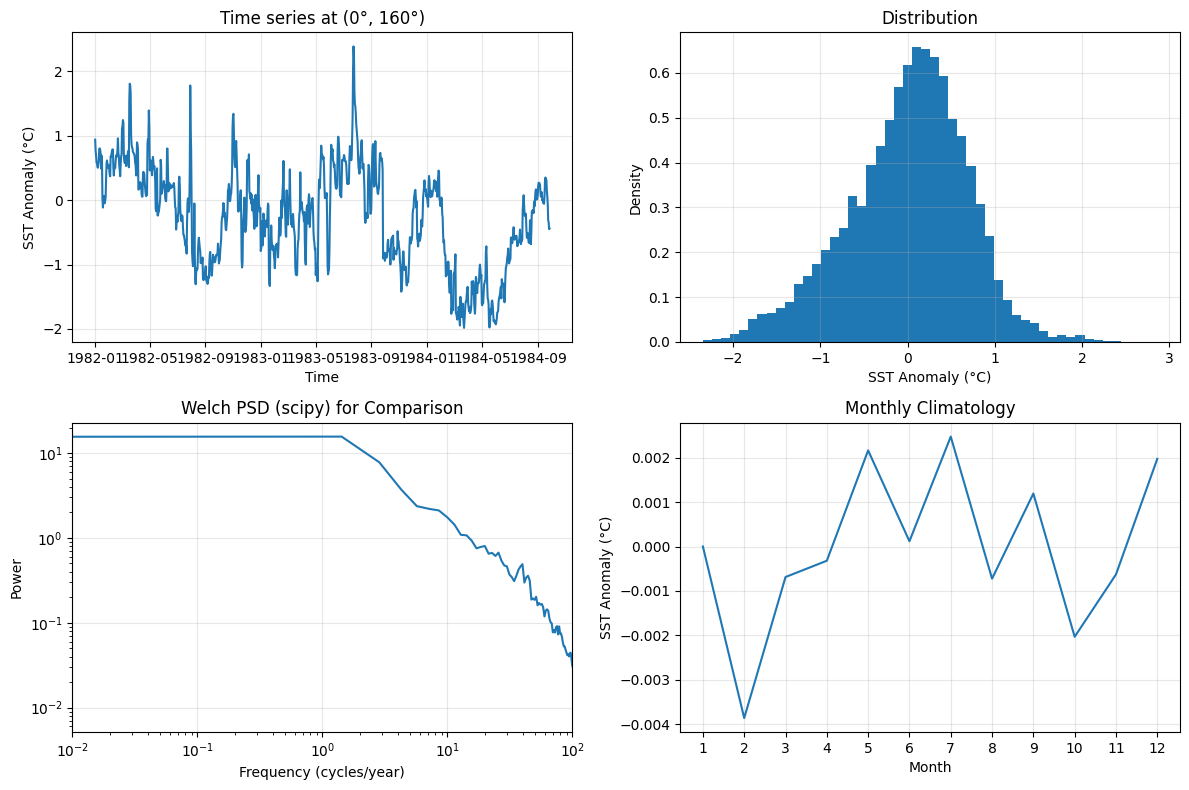

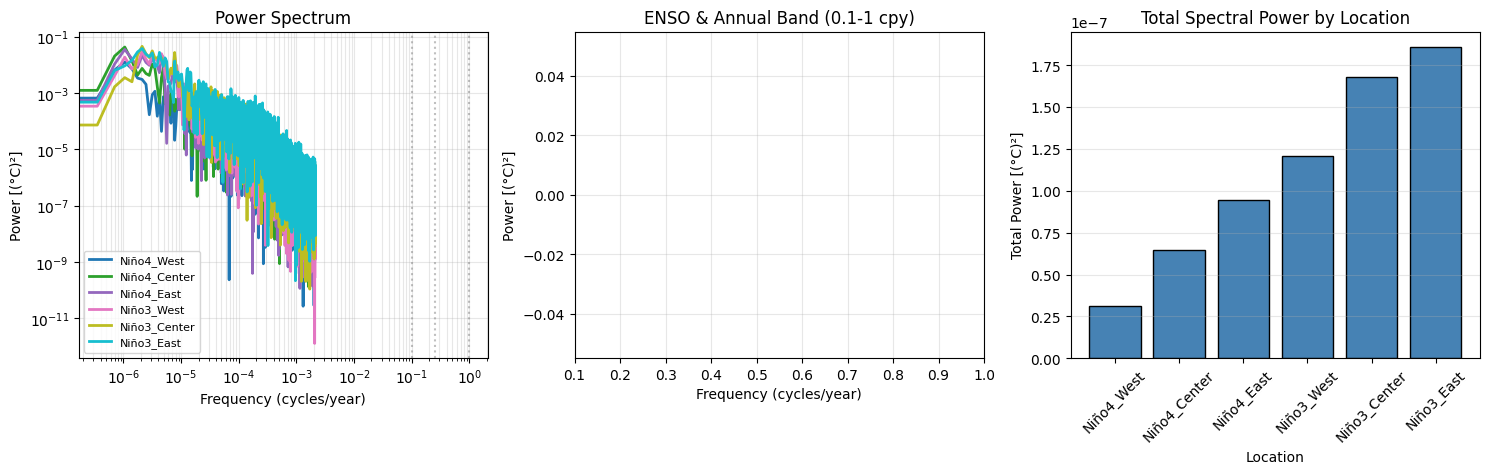


Creating quick spatial maps...


2025-12-09 13:05:28,082 - distributed.worker.memory - WARNING - Unmanaged memory use is high. This may indicate a memory leak or the memory may not be released to the OS; see https://distributed.dask.org/en/latest/worker-memory.html#memory-not-released-back-to-the-os for more information. -- Unmanaged memory: 4.99 GiB -- Worker memory limit: 7.81 GiB
2025-12-09 13:05:28,610 - distributed.worker - ERROR - Worker stream died during communication: tcp://127.0.0.1:45349
Traceback (most recent call last):
  File "/home/b/b382616/.local/lib/python3.10/site-packages/distributed/comm/tcp.py", line 228, in read
    frames_nosplit = await read_bytes_rw(stream, frames_nosplit_nbytes)
  File "/home/b/b382616/.local/lib/python3.10/site-packages/distributed/comm/tcp.py", line 367, in read_bytes_rw
    actual = await stream.read_into(chunk)  # type: ignore[arg-type]
tornado.iostream.StreamClosedError: Stream is closed

The above exception was the direct cause of the following exception:

Traceback (m

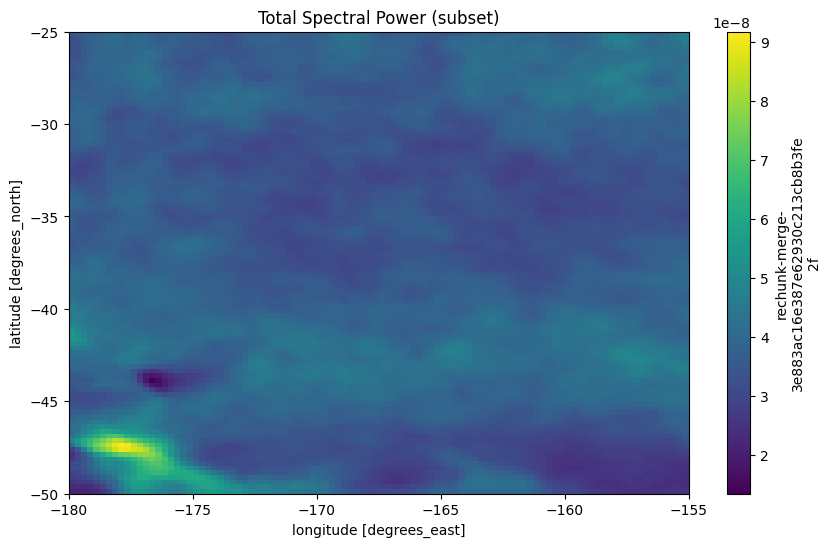


SUMMARY STATISTICS


/tmp/ipykernel_1609402/2149212267.py:323: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  total = np.trapz(psd_point.values, psd_point.freq_cpy.values)



Niño4_West (0°, 160°):
  Total variance: 0.0000 (°C)²
  ENSO band variance: 0.0000 (0.0%)


/tmp/ipykernel_1609402/2149212267.py:323: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  total = np.trapz(psd_point.values, psd_point.freq_cpy.values)



Niño4_Center (0°, 170°):
  Total variance: 0.0000 (°C)²
  ENSO band variance: 0.0000 (0.0%)


/tmp/ipykernel_1609402/2149212267.py:323: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  total = np.trapz(psd_point.values, psd_point.freq_cpy.values)



Niño4_East (0°, -170°):
  Total variance: 0.0000 (°C)²
  ENSO band variance: 0.0000 (0.0%)

Niño3_West (0°, -150°):
  Total variance: 0.0000 (°C)²
  ENSO band variance: 0.0000 (0.0%)

Analysis complete!


/tmp/ipykernel_1609402/2149212267.py:323: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  total = np.trapz(psd_point.values, psd_point.freq_cpy.values)


In [13]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import xrft

# Your points of interest
points_of_interest = [
    {"name": "Niño4_West", "lat": 0, "lon": 160},
    {"name": "Niño4_Center", "lat": 0, "lon": 170},
    {"name": "Niño4_East", "lat": 0, "lon": -170},
    {"name": "Niño3_West", "lat": 0, "lon": -150},
    {"name": "Niño3_Center", "lat": 0, "lon": -120},
    {"name": "Niño3_East", "lat": 0, "lon": -90},
]

# 1. Rechunk time dimension to single chunk (required for FFT)
print("Rechunking time dimension...")
ossta_rechunked = ossta.chunk({'time': -1})  # -1 = single chunk

# 2. Calculate power spectrum
print("Calculating power spectrum...")
psd = xrft.power_spectrum(
    da=ossta_rechunked,
    dim='time',
    scaling='spectrum',
    detrend=None,      # Your data is already detrended
    window='hann',     # Reduce spectral leakage
    nfft=None          # Use all time points
)

# 3. Keep only positive frequencies and convert to cycles/year
psd = psd.where(psd.freq_time >= 0, drop=True)
psd = psd.assign_coords(freq_cpy=psd.freq_time * 365.25)  # Daily data → cycles/year
psd = psd.rename({'freq_time': 'freq'})

# 4. Create the PSD plot
fig, ax = plt.subplots(figsize=(12, 8))

# Color palette
colors = plt.cm.tab10(np.linspace(0, 1, len(points_of_interest)))

# Plot PSD for each point
for i, point in enumerate(points_of_interest):
    # Extract PSD at this point
    psd_point = psd.sel(
        lat=point["lat"], 
        lon=point["lon"], 
        method="nearest"
    ).compute()  # Convert to numpy for plotting
    
    # Log-log plot
    ax.loglog(
        psd_point.freq_cpy,
        psd_point,
        label=f"{point['name']} ({point['lat']}°, {point['lon']}°)",
        color=colors[i],
        linewidth=2.5,
        alpha=0.9
    )

# Add frequency band annotations
ax.axvline(1, color='gray', linestyle='--', alpha=0.7, label='Annual (1 cpy)')
ax.axvline(0.25, color='red', linestyle='--', alpha=0.7, label='ENSO (4 years)')
ax.axvline(0.1, color='blue', linestyle='--', alpha=0.7, label='Decadal (10 years)')

# Highlight ENSO band
ax.axvspan(0.2, 0.5, alpha=0.1, color='red', label='ENSO band (2-5 years)')

# Formatting
ax.set_xlabel('Frequency (cycles per year)', fontsize=14, fontweight='bold')
ax.set_ylabel('Power Spectral Density [(°C)²]', fontsize=14, fontweight='bold')
ax.set_title('Power Spectrum of SST Anomalies at Key Locations', fontsize=16, fontweight='bold', pad=20)

ax.grid(True, alpha=0.3, which='both')
ax.legend(fontsize=11, loc='upper right', framealpha=0.9)

# Set reasonable limits
ax.set_xlim(0.01, 10)  # 0.01 cpy = 100-year period to 10 cpy = ~36-day period

plt.tight_layout()
plt.show()

# Print summary table
print("\n" + "="*80)
print("SUMMARY: Total Variance at Each Location")
print("="*80)
print(f"{'Location':<25} {'Total Variance':<15} {'ENSO Fraction':<15}")
print("-"*80)

for point in points_of_interest:
    psd_point = psd.sel(lat=point["lat"], lon=point["lon"], method="nearest").compute()
    
    # Total variance (integral of PSD)
    total_var = np.trapz(psd_point.values, psd_point.freq_cpy.values)
    
    # ENSO band variance (0.2-0.5 cpy)
    enso_mask = (psd_point.freq_cpy >= 0.2) & (psd_point.freq_cpy <= 0.5)
    psd_enso = psd_point.where(enso_mask, drop=True)
    if len(psd_enso.freq_cpy) > 0:
        enso_var = np.trapz(psd_enso.values, psd_enso.freq_cpy.values)
        enso_frac = (enso_var / total_var * 100)
    else:
        enso_var = 0
        enso_frac = 0
    
    print(f"{point['name']:<25} {total_var:.4f} (°C)²     {enso_frac:.1f}%")

# Power spectral density

/tmp/ipykernel_1609402/1483811156.py:40: FutureWarning: ``output_sizes`` should be given in the ``dask_gufunc_kwargs`` parameter. It will be removed as direct parameter in a future version.
  psd = xr.apply_ufunc(


Computing PSD...
PSD computed! Shape: (480, 1440, 129)


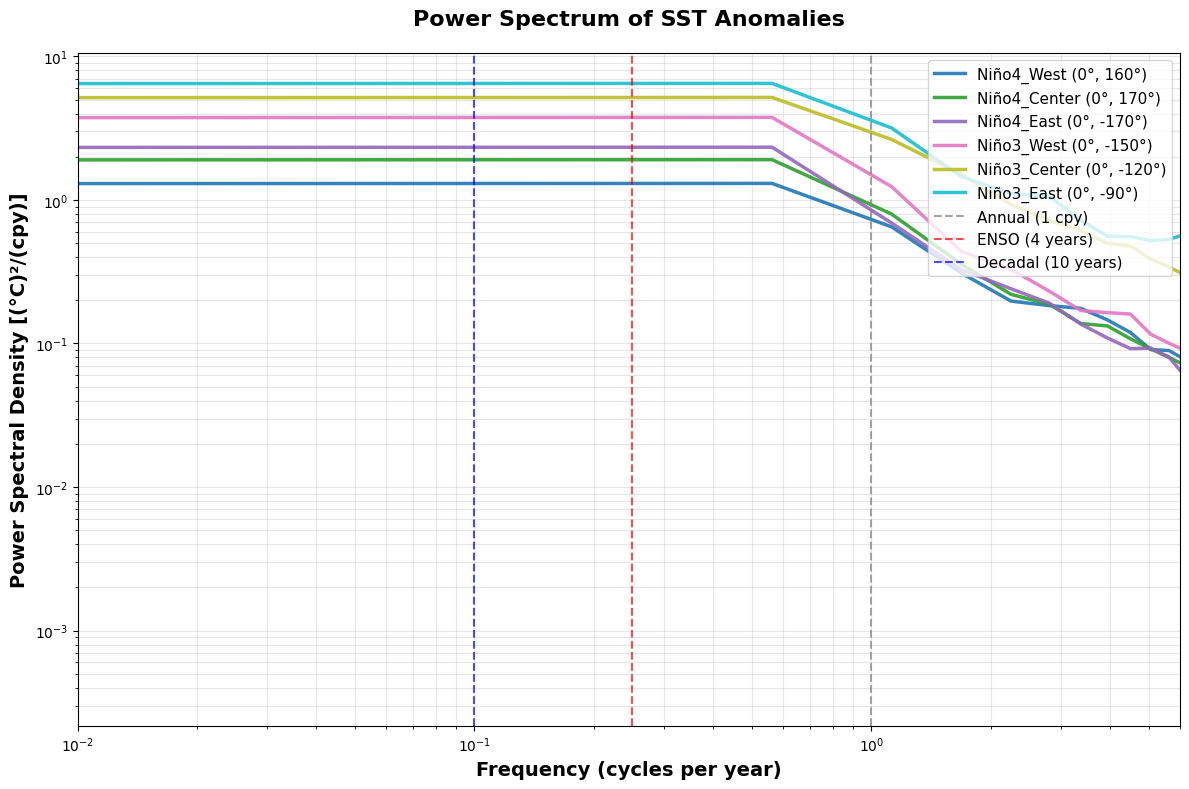


SUMMARY STATISTICS


/tmp/ipykernel_1609402/1483811156.py:151: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  total_var = np.trapz(psd_point.values, psd_point.freq_cpy.values)



Niño4_West:
  Total variance: 2.6702 (°C)²
  ENSO band variance: 0.0000 (0.0%)


/tmp/ipykernel_1609402/1483811156.py:151: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  total_var = np.trapz(psd_point.values, psd_point.freq_cpy.values)



Niño4_Center:
  Total variance: 3.1063 (°C)²
  ENSO band variance: 0.0000 (0.0%)


/tmp/ipykernel_1609402/1483811156.py:151: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  total_var = np.trapz(psd_point.values, psd_point.freq_cpy.values)



Niño4_East:
  Total variance: 3.0184 (°C)²
  ENSO band variance: 0.0000 (0.0%)


2025-12-09 13:35:42,749 - distributed.worker - ERROR - Worker stream died during communication: tcp://127.0.0.1:36805
Traceback (most recent call last):
  File "/home/b/b382616/.local/lib/python3.10/site-packages/distributed/comm/tcp.py", line 226, in read
    frames_nosplit_nbytes_bin = await stream.read_bytes(fmt_size)
tornado.iostream.StreamClosedError: Stream is closed

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/home/b/b382616/.local/lib/python3.10/site-packages/distributed/worker.py", line 2075, in gather_dep
    response = await get_data_from_worker(
  File "/home/b/b382616/.local/lib/python3.10/site-packages/distributed/worker.py", line 2881, in get_data_from_worker
    response = await send_recv(
  File "/home/b/b382616/.local/lib/python3.10/site-packages/distributed/core.py", line 1018, in send_recv
    response = await comm.read(deserializers=deserializers)
  File "/home/b/b382616/.local/lib/python3.10/sit


Niño3_West:
  Total variance: 4.5744 (°C)²
  ENSO band variance: 0.0000 (0.0%)


/tmp/ipykernel_1609402/1483811156.py:151: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  total_var = np.trapz(psd_point.values, psd_point.freq_cpy.values)


In [20]:
from scipy.signal import welch, periodogram
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

def compute_psd_xarray(da, dim='time', fs=12, method='welch', nperseg=256, **kwargs):
    """
    Compute PSD along specified dimension.
    
    Parameters:
    -----------
    da : xarray.DataArray
    dim : dimension along which to compute PSD
    fs : sampling frequency (e.g., 12 for monthly data = samples/year)
    method : 'periodogram' or 'welch'
    nperseg : segment length for Welch's method
    **kwargs : additional arguments to scipy.signal functions
    """
    # Ensure data is aligned along the dimension
    da = da.transpose(dim, ...)
    
    # Determine frequency dimension size
    if method == 'welch':
        # For Welch: nperseg//2 + 1 frequencies
        freq_size = nperseg // 2 + 1
    else:
        # For periodogram: N//2 + 1 frequencies for real signals
        N = da[dim].size
        freq_size = N // 2 + 1
    
    # Define function to apply to each grid point
    def _psd_1d(y):
        if method == 'welch':
            f, Pxx = welch(y, fs=fs, nperseg=nperseg, **kwargs)
        else:
            f, Pxx = periodogram(y, fs=fs, **kwargs)
        return Pxx
    
    # Apply along time dimension for each spatial point
    psd = xr.apply_ufunc(
        _psd_1d,
        da,
        input_core_dims=[[dim]],
        output_core_dims=[['freq']],
        output_sizes={'freq': freq_size},  # ADD THIS LINE
        vectorize=True,
        dask='parallelized' if hasattr(da.data, 'dask') else None,
        output_dtypes=[np.float64],
        kwargs=kwargs
    )
    
    # Create frequency coordinate
    if method == 'welch':
        f = np.fft.rfftfreq(nperseg, 1/fs)
    else:
        f = np.fft.rfftfreq(da[dim].size, 1/fs)
    
    psd = psd.assign_coords(freq=f)
    
    return psd

# Rechunk the data
ossta = ossta.chunk(chunks={'time': -1, 'lat': 50, 'lon': 50})

# Compute PSD
print("Computing PSD...")
psd = compute_psd_xarray(
    ossta, 
    dim='time', 
    fs=12,  # monthly data
    method='welch',
    nperseg=256
)

print(f"PSD computed! Shape: {psd.shape}")

# Define your points of interest
points_of_interest = [
    {"name": "Niño4_West", "lat": 0, "lon": 160},
    {"name": "Niño4_Center", "lat": 0, "lon": 170},
    {"name": "Niño4_East", "lat": 0, "lon": -170},
    {"name": "Niño3_West", "lat": 0, "lon": -150},
    {"name": "Niño3_Center", "lat": 0, "lon": -120},
    {"name": "Niño3_East", "lat": 0, "lon": -90},
]

# ====================
# PLOTTING CODE
# ====================

# Convert frequency to cycles per year
psd = psd.assign_coords(freq_cpy=psd.freq * 12)  # Convert cycles/month to cycles/year

# Create figure
fig, ax = plt.subplots(figsize=(12, 8))

# Color palette
colors = plt.cm.tab10(np.linspace(0, 1, len(points_of_interest)))

# Plot PSD for each point
for i, point in enumerate(points_of_interest):
    try:
        # Extract PSD at this point
        psd_point = psd.sel(
            lat=point["lat"], 
            lon=point["lon"], 
            method="nearest"
        ).compute()  # Convert dask array to numpy
        
        # Log-log plot
        ax.loglog(
            psd_point.freq_cpy,
            psd_point,
            label=f"{point['name']} ({point['lat']}°, {point['lon']}°)",
            color=colors[i],
            linewidth=2.5,
            alpha=0.9
        )
    except Exception as e:
        print(f"Error plotting {point['name']}: {e}")

# Add frequency band annotations
ax.axvline(1, color='gray', linestyle='--', alpha=0.7, label='Annual (1 cpy)')
ax.axvline(0.25, color='red', linestyle='--', alpha=0.7, label='ENSO (4 years)')
ax.axvline(0.1, color='blue', linestyle='--', alpha=0.7, label='Decadal (10 years)')

# Formatting
ax.set_xlabel('Frequency (cycles per year)', fontsize=14, fontweight='bold')
ax.set_ylabel('Power Spectral Density [(°C)²/(cpy)]', fontsize=14, fontweight='bold')
ax.set_title('Power Spectrum of SST Anomalies', fontsize=16, fontweight='bold', pad=20)

ax.grid(True, alpha=0.3, which='both')
ax.legend(fontsize=11, loc='upper right')

# Set reasonable limits
ax.set_xlim(0.01, 6)  # 0.01 cpy = 100-year period to 6 cpy = 2-month period

plt.tight_layout()
plt.show()

# Optional: Print summary statistics
print("\n" + "="*80)
print("SUMMARY STATISTICS")
print("="*80)

for point in points_of_interest[:4]:  # First 4 points for brevity
    try:
        psd_point = psd.sel(lat=point["lat"], lon=point["lon"], method="nearest").compute()
        
        # Total variance (integral of PSD)
        total_var = np.trapz(psd_point.values, psd_point.freq_cpy.values)
        
        # ENSO band variance (0.2-0.5 cpy)
        enso_mask = (psd_point.freq_cpy >= 0.2) & (psd_point.freq_cpy <= 0.5)
        psd_enso = psd_point.where(enso_mask, drop=True)
        if len(psd_enso.freq_cpy) > 0:
            enso_var = np.trapz(psd_enso.values, psd_enso.freq_cpy.values)
            enso_frac = (enso_var / total_var * 100)
        else:
            enso_var = 0
            enso_frac = 0
        
        print(f"\n{point['name']}:")
        print(f"  Total variance: {total_var:.4f} (°C)²")
        print(f"  ENSO band variance: {enso_var:.4f} ({enso_frac:.1f}%)")
        
    except Exception as e:
        print(f"Error with {point['name']}: {e}")

In [18]:
ossta=ossta.chunk(chunks={'time': -1, 'lat': 50, 'lon': 50})
'linear'
)

/tmp/ipykernel_1609402/1487441620.py:39: FutureWarning: ``output_sizes`` should be given in the ``dask_gufunc_kwargs`` parameter. It will be removed as direct parameter in a future version.
  psd = xr.apply_ufunc(
